# Computational Modeling Project 7

The scheme is to use Metrpolis slgorithm for 1D boltzmann. 
We use the distribution:

$$ \pi(x) ~ e^{-\beta \textbf{U}(x)}$$

Where $\textbf{U}(x) \in \mathcal {C}(\mathbb{R})$ is a potential function, $\beta = \dfrac{1}{T}$. We take the values for $T$ provided in the work sheet $T \in \lbrace 1.0 , 0.5, 0.2 \rbrace$.

In [1]:
# as always
import numpy as np
import matplotlib.pyplot as plt

For our example we use $\mathbf{U}(x) = x^4 - x^2$

In [2]:
# potential function
def U(x):
    return x**4 - x**2

The choice of parameters is:

- $T$ Temperature
- $L$ Parameter for Uniform distirbution of $L$
- $N$ Number of iterations of algorithm.
- Initial Position

In [3]:
temperatures = [1.0, 0.5, 0.2]
L = 0.3
N = 500000
x_0 = 0.0

## Part (a)

(1)

In [4]:
# Definition of walk vector

x = np.array([x_0])

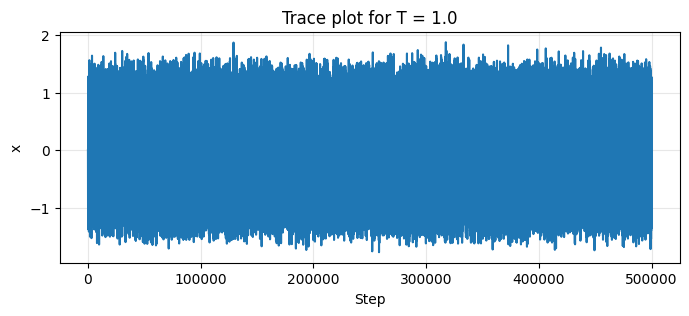

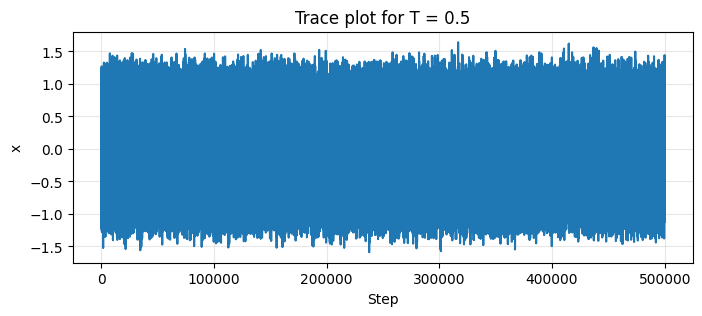

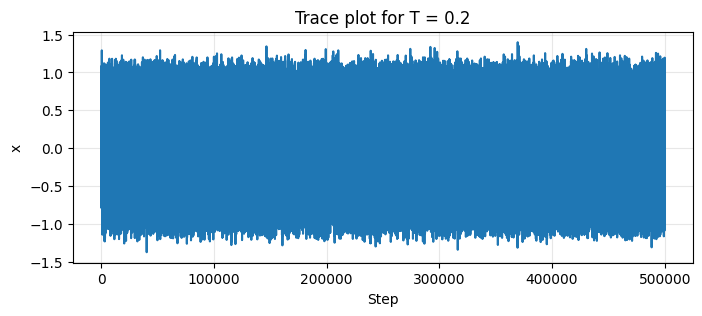

In [5]:
def metropolis(T, N=N, x_0=x_0, L=L, dbg=False):
    x = np.empty(N + 1)
    x[0] = x_0
    accepted = 0

    for i in range(N):
        step = np.random.uniform(-L, L)
        trial = x[i] + step
        dU = U(trial) - U(x[i])
        p_acc = min(1.0, np.exp(-dU / T))

        if np.random.rand() < p_acc:
            x[i + 1] = trial
            accepted += 1
        else:
            x[i + 1] = x[i]

    acc_rate = accepted / N

    if dbg:
        print(
            f"for parameters:\n N = {N}\n T = {T}\n L = {L}\n x_0 = {x_0}\n acceptance rate is {acc_rate}"
        )

    return x, acc_rate


# to see it:
for T in temperatures:
    samples, _ = metropolis(T)
    plt.figure(figsize=(8, 3))
    plt.plot(samples)
    plt.title(f"Trace plot for T = {T}")
    plt.xlabel("Step")
    plt.ylabel("x")
    plt.grid(alpha=0.3)
    plt.show()

This is a good symmetric proposal given that the uniform distribution is symmetric like the potential function

Good values of L for the range of uniform distribution of $L$ was $L= 0.001$ to get less noise.

# Part (b) 

compare the empirical stationary distribution obtained from the Metropolis chain to the theoretical Boltzmann density

$$
\pi(x) \propto e^{-\beta U(x)}, \qquad U(x)=x^4-x^2.
$$

For each temperature $T \in \{1.0, 0.5, 0.2\}$

1. run the Metropolis chain,
2. discard an initial burn-in portion,
3. estimate the density $\hat{\pi}(x)$ using a normalized histogram,
4. compute the normalized reference density numerically on a sufficiently wide interval,
5. plot both together and comment on their agreement.

In [6]:
def reference_density(T, x_min=-2.5, x_max=2.5, n_grid=2000):
    x_grid = np.linspace(x_min, x_max, n_grid)
    w = np.exp(-U(x_grid) / T)
    Z = np.trapezoid(w, x_grid)
    pi_ref = w / Z
    return x_grid, pi_ref


I use the same Metropolis procedure for all three temperatures.  
The burn-in samples are discarded before constructing the histogram estimate.

In [7]:
burn_in = 200000     # discard initial transient

bins = 120
x_min, x_max = -2.5, 2.5

In [8]:
results = {}

for T in temperatures:
    chain, acc_rate = metropolis(T, dbg=True)
    samples = chain[burn_in:]
    x_grid, pi_ref = reference_density(T, x_min=x_min, x_max=x_max)

    results[T] = {
        "chain": chain,
        "samples": samples,
        "acc_rate": acc_rate,
        "x_grid": x_grid,
        "pi_ref": pi_ref
    }

for parameters:
 N = 500000
 T = 1.0
 L = 0.3
 x_0 = 0.0
 acceptance rate is 0.916106
for parameters:
 N = 500000
 T = 0.5
 L = 0.3
 x_0 = 0.0
 acceptance rate is 0.885186
for parameters:
 N = 500000
 T = 0.2
 L = 0.3
 x_0 = 0.0
 acceptance rate is 0.80479


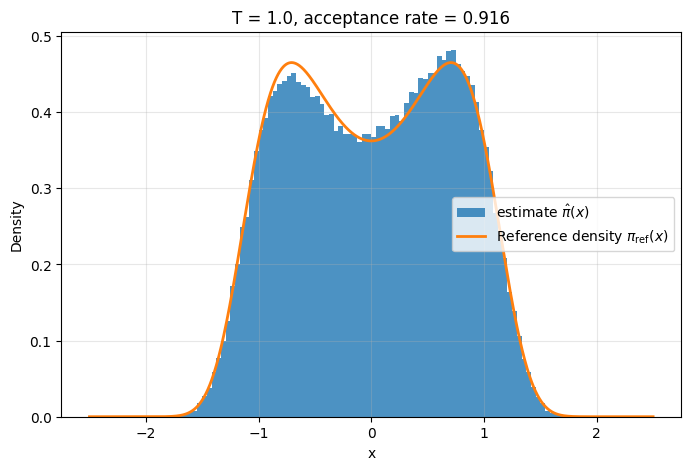

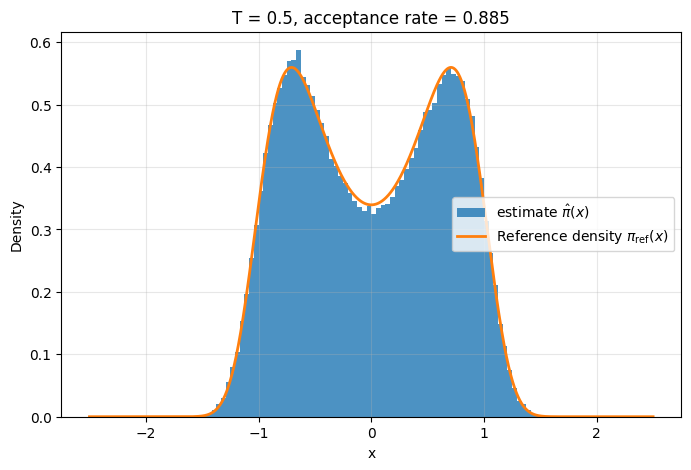

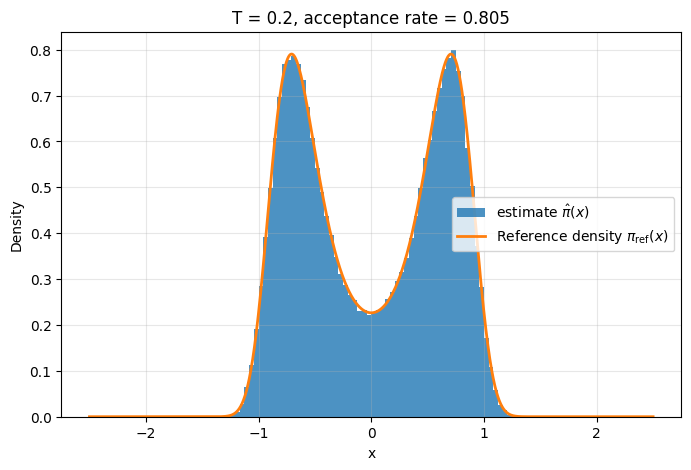

In [9]:
for T in temperatures:
    samples = results[T]["samples"]
    x_grid = results[T]["x_grid"]
    pi_ref = results[T]["pi_ref"]
    acc_rate = results[T]["acc_rate"]

    plt.figure(figsize=(8, 5))
    plt.hist(samples, bins=bins, range=(x_min, x_max), density=True, alpha=0.8, label=r"estimate $\hat{\pi}(x)$")
    plt.plot(x_grid, pi_ref, linewidth=2, label=r"Reference density $\pi_{\mathrm{ref}}(x)$")

    plt.xlabel("x")
    plt.ylabel("Density")
    plt.title(f"T = {T}, acceptance rate = {acc_rate:.3f}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

_Choice of numerical integration interval_

To normalize the reference density, I approximated the integral on the interval

$$
[x_{\min}, x_{\max}] = [-2.5, 2.5].
$$

This interval is sufficiently wide for the present temperatures because the term $e^{-\beta(x^4-x^2)}$ becomes very small in the tails, so the contribution outside this range is negligible.

#### Comments on the agreement

The histogram should approximately follow the reference Boltzmann density in all three cases.

Expected qualitative behavior as the temperature decreases:

- At higher temperature $(T=1.0)$, the distribution is broader and transitions between the two wells occur more easily.
- At intermediate temperature $(T=0.5)$, the two-well structure becomes more pronounced.
- At lower temperature $(T=0.2)$, the probability mass concentrates more strongly near the minima of the double-well potential, and mixing between wells becomes slower.

Small discrepancies between the histogram and the reference curve are expected because the histogram is based on a finite sample and because low-temperature chains mix more slowly.

# Part (c)

how is the proposal of half-width $L$ affect the Metropolis sampler?

For each temperature $$ \in $\{1.0, 0.5, 0.2\}\$,
1. scan $L$ over a reasonable range,
2. run the Metropolis chain,
3. record the acceptance rate,
4. plot acceptance rate versus $L$,
5. choose an “optimal” $L$ by balancing acceptance and exploration.



A very small $L$ gives a high acceptance rate, but the chain moves only in tiny steps and explores the state space slowly.

A very large $L$ gives larger proposed moves, but many of them are rejected, which also reduces effective exploration.

Therefore, choose $L$ by looking for:
- acceptance rate not too close to 0,
- acceptance rate not trivially close to 1,
- sufficiently large moves so that the chain explores both wells in a reasonable time.


look for $L$ over a logarithmically spaced range and compute the acceptance rate for each value.

In [10]:
N_count = 50000
x0 = 0.2

L_list = np.logspace(-2, 0.5, 20)

In [11]:
acceptance_results = {}

for T in temperatures:
    acc = []

    for L in L_list:
        _, acc_rate = metropolis(T=T, N=N_count, x_0=x0, L=L)
        acc.append(acc_rate)

    acceptance_results[T] = np.array(acc)

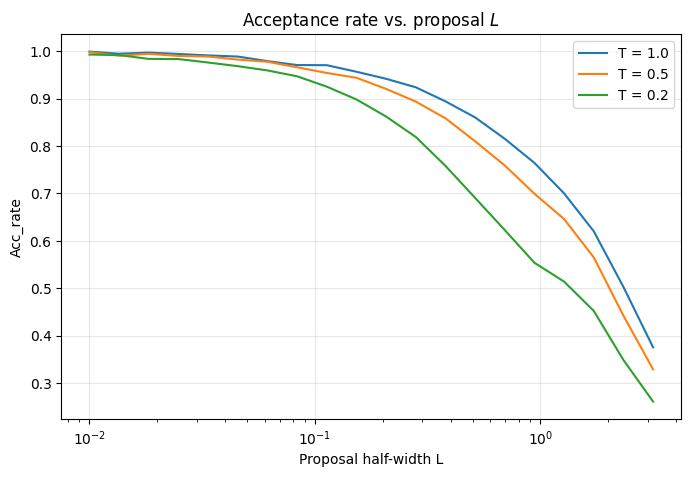

In [23]:
plt.figure(figsize=(8, 5))

for T in temperatures:
    plt.semilogx(L_list, acceptance_results[T], label=f"T = {T}")

plt.xlabel(r"Proposal half-width L")
plt.ylabel("Acc_rate")
plt.title("Acceptance rate vs. proposal $L$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [13]:
target_acc = 0.5

L_opt = {
    T: float(L_list[np.argmin(np.abs(acceptance_results[T] - target_acc))])
    for T in temperatures
}

L_opt

{1.0: 2.3357214690901213, 0.5: 2.3357214690901213, 0.2: 1.2742749857031335}

## Part (d)

DEfine some well index based on the position of $x_t$ if it belongs to one of the wells such that:

$$ w_t = \mathrm{sign}(x_t) \in \{-1, +1\}$$

so we:
1. estimate the switching rate between wells,
2. compute first-passage times for changing sign,
3. explain why low-temperature chains can appear stationary while still mixing poorly.

In [14]:
def well(x):
    w = np.sign(x)
    for i in range(1, len(w)):
        if w[i] == 0:
            w[i] = w[i - 1]
    if len(w) > 0 and w[0] == 0:
        w[0] = 1
    return w.astype(int)


def switching_rate(chain, burn_in=0):
    x_post = chain[burn_in:]
    w = well(x_post)
    switches = np.sum(w[1:] != w[:-1])
    rate = switches / (len(w) - 1)
    return switches, rate

In [15]:
N_mix = 200000
burn_in_mix = 20000
x0_mix = 1.0

switching_results = {}

for T in temperatures:
    L = L_opt[T]
    chain, acc_rate = metropolis(T=T, N=N_mix, x_0=x0_mix, L=L)
    switches, rate = switching_rate(chain, burn_in=burn_in_mix)

    switching_results[T] = {
        "chain": chain,
        "acc_rate": acc_rate,
        "switches": switches,
        "switch_rate": rate
    }

    print(f"T = {T}, L = {L:.4f}, switches = {switches}, switching rate = {rate:.6f}")

T = 1.0, L = 2.3357, switches = 44304, switching rate = 0.246133
T = 0.5, L = 2.3357, switches = 39561, switching rate = 0.219783
T = 0.2, L = 1.2743, switches = 34826, switching rate = 0.193478


In [16]:
def first_passage_time(T, L, x0, max_steps=200000):
    x = x0
    s0 = np.sign(x0)

    if s0 == 0:
        raise ValueError("x0 should be strictly positive or strictly negative.")

    for t in range(1, max_steps + 1):
        step = np.random.uniform(-L, L)
        trial = x + step
        dU = U(trial) - U(x)
        p_acc = min(1.0, np.exp(-dU / T))

        if np.random.rand() < p_acc:
            x = trial

        s = np.sign(x)
        if s != 0 and s != s0:
            return t

    return np.nan

In [17]:
n_trials = 500
max_steps_fpt = 200000

fpt_results = {}

for T in temperatures:
    L = L_opt[T]

    fpt_pos = np.array([
        first_passage_time(T=T, L=L, x0=1.0, max_steps=max_steps_fpt)
        for _ in range(n_trials)
    ])

    fpt_neg = np.array([
        first_passage_time(T=T, L=L, x0=-1.0, max_steps=max_steps_fpt)
        for _ in range(n_trials)
    ])

    fpt_results[T] = {
        "from_pos": fpt_pos,
        "from_neg": fpt_neg
    }

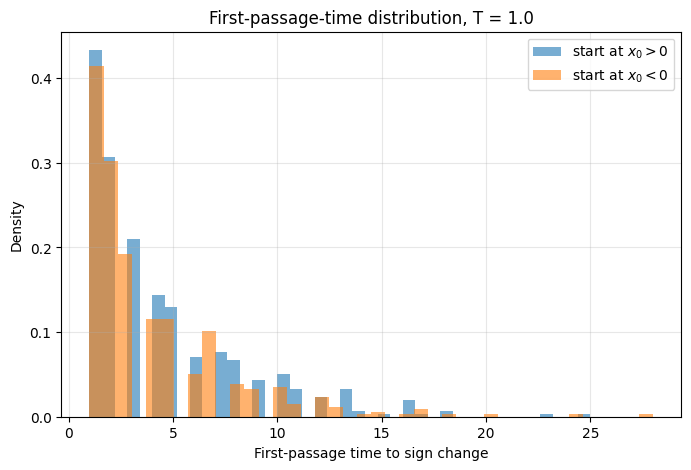

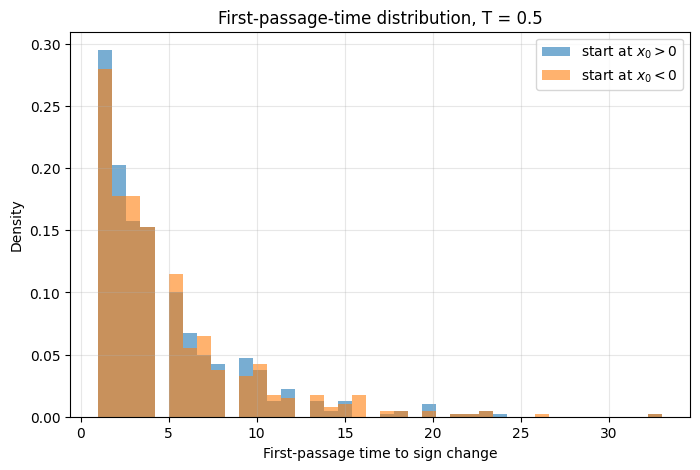

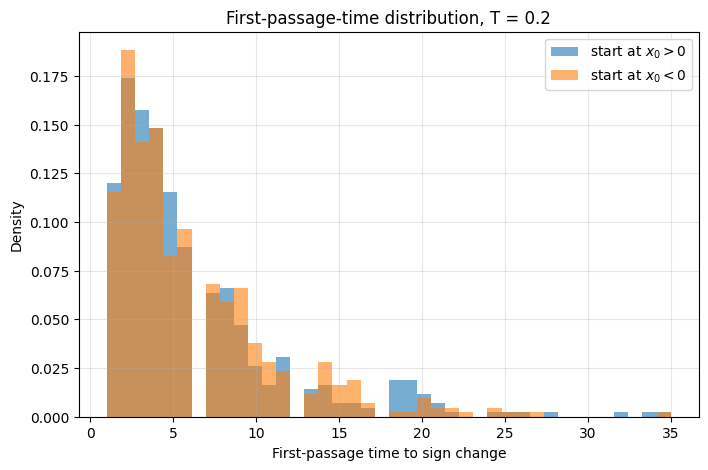

In [18]:
for T in temperatures:
    fpt_pos = fpt_results[T]["from_pos"]
    fpt_neg = fpt_results[T]["from_neg"]

    plt.figure(figsize=(8, 5))
    plt.hist(fpt_pos[~np.isnan(fpt_pos)], bins=40, alpha=0.6, density=True, label=r"start at $x_0>0$")
    plt.hist(fpt_neg[~np.isnan(fpt_neg)], bins=40, alpha=0.6, density=True, label=r"start at $x_0<0$")

    plt.xlabel("First-passage time to sign change")
    plt.ylabel("Density")
    plt.title(f"First-passage-time distribution, T = {T}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [19]:
for T in temperatures:
    fpt_pos = fpt_results[T]["from_pos"]
    fpt_neg = fpt_results[T]["from_neg"]

    mean_pos = np.nanmean(fpt_pos)
    mean_neg = np.nanmean(fpt_neg)

    print(f"T = {T}")
    print(f"  Mean FPT from x0 > 0: {mean_pos:.2f}")
    print(f"  Mean FPT from x0 < 0: {mean_neg:.2f}")

T = 1.0
  Mean FPT from x0 > 0: 4.30
  Mean FPT from x0 < 0: 3.91
T = 0.5
  Mean FPT from x0 > 0: 4.56
  Mean FPT from x0 < 0: 4.75
T = 0.2
  Mean FPT from x0 > 0: 6.09
  Mean FPT from x0 < 0: 6.07


_Interpretation: metastability at low temperature_:

At low temperature, transitions between the two wells become improbable.

The chain can therefore remain for a very long time in one well, and the local trace may look stable or “stationary.”  this apparent stationarity is misleading: the chain is only exploring one metastable region and is not mixing efficiently across the full target distribution.

This is metastability:
- the within-well motion may equilibrate quickly,
- but barrier crossing between wells occurs on a much longer timescale.



# Part (e)


compute the mean squared jump distance

$$
\mathrm{MSJD} = \left\langle (x_{t+1} - x_t)^2 \right\rangle
$$

for the Metropolis chain and study how it depends on the proposal half-width $L$.

For each temperature $T \in \{1.0, 0.5, 0.2\}$, I:
1. use the same $L$-grid as in Part (c),
2. run the chain for each $L$,
3. compute the MSJD from the recorded trajectory,
4. plot MSJD versus $L$,
5. use the result to justify the “optimal” $L$.

The MSJD provides a more quantitative measure of exploration than the acceptance rate alone.

In [20]:
def msjd(chain):
    dx = np.diff(chain)
    return np.mean(dx**2)


msjd_results = {}

for T in temperatures:
    vals = []

    for L in L_list:
        chain, _ = metropolis(T=T, N=N_count, x_0=x0, L=L)
        vals.append(msjd(chain))

    msjd_results[T] = np.array(vals)

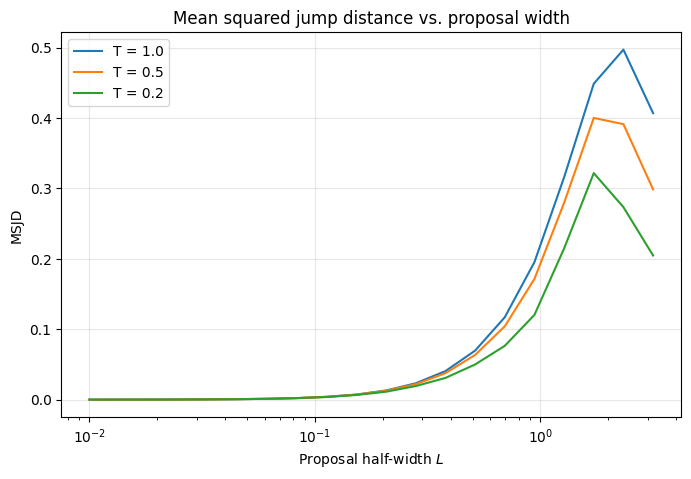

{1.0: 2.3357214690901213, 0.5: 1.725210549942041, 0.2: 1.725210549942041}

In [22]:
plt.figure(figsize=(8, 5))

for T in temperatures:
    plt.semilogx(L_list, msjd_results[T], label=f"T = {T}")

plt.xlabel(r"Proposal half-width $L$")
plt.ylabel("MSJD")
plt.title("Mean squared jump distance vs. proposal width")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

L_opt_msjd = {
    T: float(L_list[np.argmax(msjd_results[T])])
    for T in temperatures
}

L_opt_msjd

# Part (F)

test convergence at low temperature by running two independent Metropolis chains with the same proposal width.

I use:
- chain A starting from $x_0=-1$,
- chain B starting from $x_0=+1$,

and compare their histograms after the same burn-in.

If both chains have converged to the same stationary distribution, then their post-burn-in histograms should look similar. If they remain noticeably different, this indicates slow mixing and incomplete convergence.

##### setup

The project asks for a low-temperature comparison, so I use

\[
T = 0.2
\]

and the same proposal width for both chains. The two initial conditions are chosen in opposite wells in order to test whether the chains forget their starting points within the available simulation time.

In [45]:
# parameters
T_low = 0.5
L_same = L_opt_msjd[T_low]

N_two = 200000
burn_in_two = 20000

x0_A = -1.0
x0_B =  1.0

In [46]:
chain_A, acc_A = metropolis(T=T_low, N=N_two, x_0=x0_A, L=L_same)
chain_B, acc_B = metropolis(T=T_low, N=N_two, x_0=x0_B, L=L_same)

samples_A = chain_A[burn_in_two:]
samples_B = chain_B[burn_in_two:]

print(f"Chain A acceptance rate: {acc_A:.4f}")
print(f"Chain B acceptance rate: {acc_B:.4f}")

Chain A acceptance rate: 0.5619
Chain B acceptance rate: 0.5611


### plots

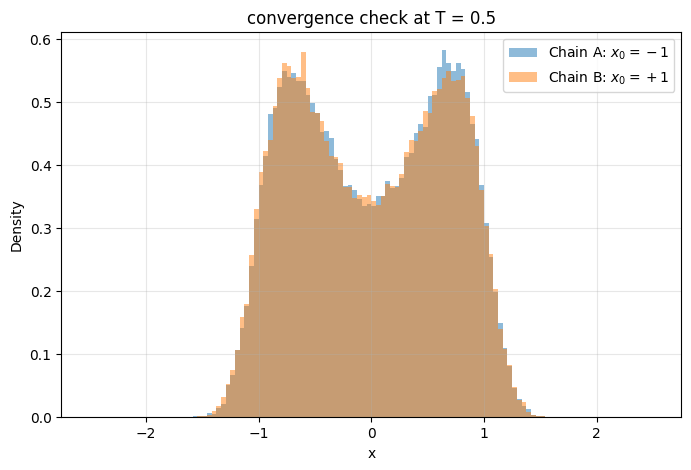

In [47]:
plt.figure(figsize=(8, 5))

plt.hist(samples_A,bins=120, range=(x_min, x_max),density=True,alpha=0.5,label=r"Chain A: $x_0=-1$")

plt.hist(samples_B, bins=120, range=(x_min, x_max), density=True, alpha=0.5, label=r"Chain B: $x_0=+1$")

plt.xlabel("x")
plt.ylabel("Density")
plt.title(f"convergence check at T = {T_low}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [29]:
print("Chain A:")
print(f"  mean = {np.mean(samples_A):.4f}")
print(f"  var  = {np.var(samples_A):.4f}")

print("Chain B:")
print(f"  mean = {np.mean(samples_B):.4f}")
print(f"  var  = {np.var(samples_B):.4f}")

Chain A:
  mean = 0.0045
  var  = 0.4163
Chain B:
  mean = 0.0027
  var  = 0.4141
